## Statistical comparison of AWS Arctic retrievals and EarthCARE

This notebook plots 1D histograms and 2D conditional distributions of **collocated** AWS FWP (or LWP) and EarthCARE IWP (or LWP).
The actual statistics are computed using ``compute_aws_earthcare_coloc_stats.py``, which loads the collocations, averages over EarthCARE data, and calculates the histograms.

In [7]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import xarray as xr
import pickle
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import cmocean as cmc

sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import utils
import plot_utils

plt.style.use("../plotstyling.mplstyle")

In [8]:
date_str = "2025-07_to_2026-06"
quantity = "fwp"   # or "lwp"
months = utils.calendar_months(date_str)

variable_label = quantity.upper()
ea_label = "IWP" if quantity == "fwp" else "LWP"   # EarthCARE quantity compared with AWS
period_label = date_str.replace("_to_", " to ").replace("_", ", ")


with open(f"../data/aws_earthcare_histograms_surface_{date_str}.pkl", "rb") as f:
    h_all = pickle.load(f)
h = h_all[quantity]

# all counts are per surface type: h["aws_counts"][i] belongs to surface_types[i]
surface_types = h["surface_types"]
print("AWS samples per surface:", dict(zip(surface_types, h["aws_n"])))
print("unclassified:", h["n_unclassified"])

bins = h["bins"]
bin_widths = np.diff(bins)
bin_centres = np.sqrt(bins[:-1] * bins[1:])
bin_centres[0] = 5e-5   # stand-in for the 0 to 1e-4 bin

AWS samples per surface: {'ocean': np.int64(47098), 'seaice': np.int64(182871), 'land': np.int64(10201), 'water': np.int64(0), 'snow': np.int64(94511), 'glacier': np.int64(20789)}
unclassified: 83772


In [9]:
# load simulation data and filter for same timeframe


ds_training = xr.open_dataset("/scratch/evoy/easy_arts_output/AWS/2026-03-08_arctic_run1/combined_2026-03-08_run0_run1_2026-02-05_2026-01-20_training.nc")

db_times = pd.DatetimeIndex(ds_training.CloudSat_Datetime.values)
db_values = ds_training[quantity.capitalize()].values
in_months = np.isin(db_times.month, months)

# surface type of each database case: the one with the largest fraction,
# only if that fraction is above 0.5 (-1 otherwise)
db_frac = ds_training["SurfaceType"].transpose("number", "surface_type").values
db_frac = np.where(np.isfinite(db_frac), db_frac, -1.0)
db_surface = np.argmax(db_frac, axis=1)
db_surface[db_frac.max(axis=1) <= 0.5] = -1

# database surface index for each AWS surface type name
# (assumes the database and the AWS files list the surface types in the same order)
db_surface_index = {name: i for i, name in enumerate(surface_types)}

print(f"{in_months.sum()} of {in_months.size} database cases in months {months}")
for name in surface_types:
    n = np.sum(in_months & (db_surface == db_surface_index[name]))
    print(f"  {name:>8s}: {n}")

db_years = ", ".join(str(y) for y in np.unique(db_times.year[in_months]))
db_label = f"AWS simulations ({db_years})"

1830313 of 1830313 database cases in months [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
     ocean: 487241
    seaice: 676904
      land: 145189
     water: 3366
      snow: 507874
   glacier: 1867


water: no collocations, skipping


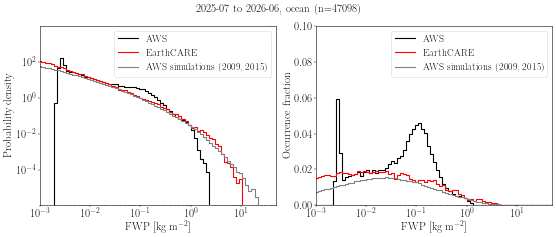

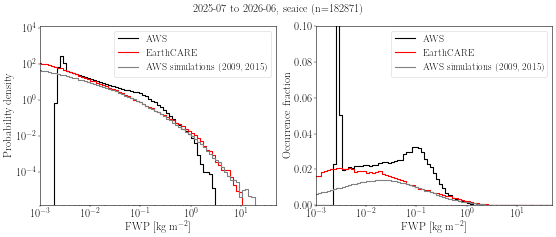

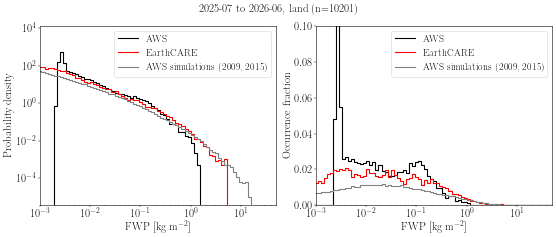

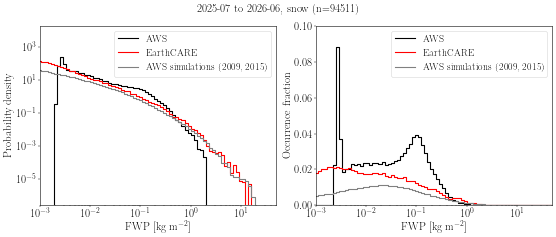

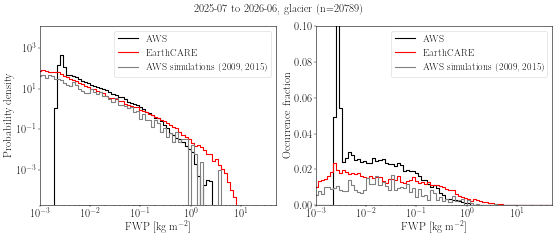

In [10]:
for i_s, surface in enumerate(surface_types):
    total_aws_counts = h["aws_counts"][i_s]
    total_ea_counts = h["ea_counts"][i_s]
    total_aws_n = h["aws_n"][i_s]
    total_ea_n = h["ea_n"][i_s]
    if total_aws_n == 0:
        print(f"{surface}: no collocations, skipping")
        continue

    # database cases in the same months and on the same surface
    values = db_values[in_months & (db_surface == db_surface_index[surface])]
    with np.errstate(invalid="ignore", divide="ignore"):
        database_pdf, _ = np.histogram(values, bins=bins, density=True)
        database_counts, _ = np.histogram(values, bins=bins)
        database_occ_frac = database_counts / values.size

    aws_hist_density = total_aws_counts / (total_aws_n * bin_widths)
    ea_hist_density = total_ea_counts / (total_ea_n * bin_widths)

    # occurrence fractions: counts / total, so each sums to 1 over all bins
    aws_occ_frac = total_aws_counts / total_aws_n
    ea_occ_frac = total_ea_counts / total_ea_n


    fig, (ax_pdf, ax_of) = plt.subplots(1, 2, figsize=(14, 6))

    # probability density
    ax_pdf.step(bin_centres, aws_hist_density, where="mid", lw=2,
                color="black", label="AWS")
    ax_pdf.step(bin_centres, ea_hist_density, where="mid", lw=2,
                color="red", label="EarthCARE")
    ax_pdf.step(bin_centres, database_pdf, where="mid", lw=2,
                color="grey", label=db_label)
    ax_pdf.set_yscale("log")
    ax_pdf.set_ylabel("Probability density")
    #ax_pdf.set_ylim([1e-4, 5e2])

    # occurrence fraction
    ax_of.step(bin_centres, aws_occ_frac, where="mid", lw=2,
               color="black", label="AWS")
    ax_of.step(bin_centres, ea_occ_frac, where="mid", lw=2,
               color="red", label="EarthCARE")
    ax_of.step(bin_centres, database_occ_frac, where="mid", lw=2,
               color="grey", label=db_label)
    ax_of.set_ylabel("Occurrence fraction")
    ax_of.set_ylim([0, 0.1])

    for ax in (ax_pdf, ax_of):
        ax.set_xscale("log")
        ax.set_xlim(1e-3, 5e1)
        ax.set_xlabel(rf"{variable_label} [kg m$^{{-2}}$]")
        ax.legend()

    fig.suptitle(f"{period_label}, {surface} (n={total_aws_n})", fontsize = 20)

    fig.tight_layout()
    plt.savefig(f"../figures/collocation_statistics/aws_earthcare_{quantity}_distributions_{date_str}_{surface}.png",
                facecolor="white", bbox_inches="tight", dpi=200)

True
True
True


/home/maye/AWS_Arctic/scripts/plot_utils.py:444: RuntimeWarning: invalid value encountered in divide
  p_xy = counts_xy / (n_total * bin_area)


True
water: no EarthCARE bin with 10 or more pairs, skipping
True
True


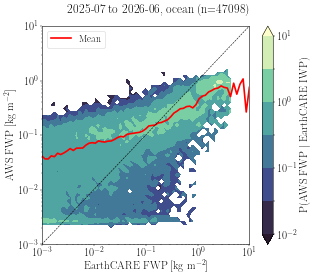

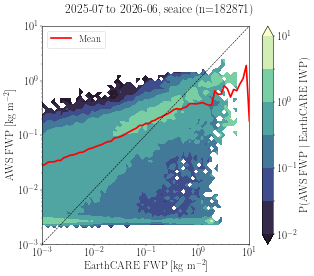

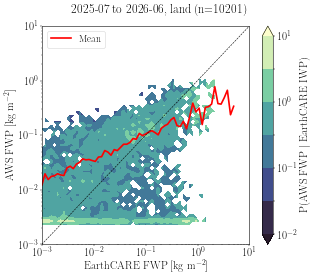

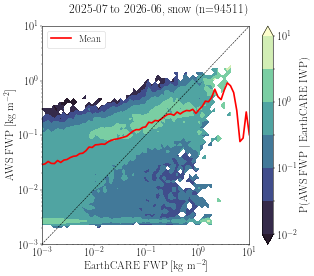

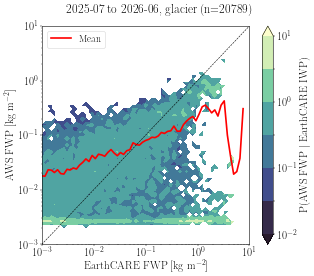

In [11]:
# ------------------------------------------------------------
# data: joint_counts rows = EarthCARE (x), columns = AWS (y)
# ------------------------------------------------------------
centres = np.sqrt(bins[:-1] * bins[1:])
min_count = 10
levels = np.logspace(-2, 1, 7)

for i_s, surface in enumerate(surface_types):
    counts = h["joint_counts"][i_s]
    total_aws_n = h["aws_n"][i_s]

    p_aws_given_ea, counts_ea, conditional_mean_aws_given_ea = plot_utils.conditional_probability_from_counts(
        counts, bins, bins, centres, log=True
    )
    if not np.any(counts_ea >= min_count):
        print(f"{surface}: no EarthCARE bin with {min_count} or more pairs, skipping")
        continue

    # blank empty cells and EarthCARE bins with too few pairs
    p_plot = np.where(p_aws_given_ea > 0, p_aws_given_ea, np.nan)
    p_plot[:, counts_ea < min_count] = np.nan

    # mean and median AWS value in each EarthCARE bin
    joint = counts.T   # rows = AWS, columns = EarthCARE
    with np.errstate(invalid="ignore", divide="ignore"):
        mean_aws = (joint * centres[:, None]).sum(axis=0) / counts_ea
    mean_aws[counts_ea < min_count] = np.nan

    cum = np.cumsum(joint, axis=0)
    median_aws = np.full(joint.shape[1], np.nan)
    for j in range(joint.shape[1]):
        if counts_ea[j] >= min_count:
            median_aws[j] = centres[np.searchsorted(cum[:, j], counts_ea[j] / 2)]

    # ------------------------------------------------------------
    # plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 7))
    cf = ax.contourf(centres, centres, p_plot,
                     levels=levels, norm=LogNorm(), cmap=cmc.cm.deep_r, extend="both")
    fig.colorbar(cf, ax=ax, label=f"P(AWS {variable_label} $|$ EarthCARE {ea_label})")


    ax.plot(centres, conditional_mean_aws_given_ea, color="red", lw=3, label="Mean")
    #ax.plot(centres, median_aws, color="magenta", lw=2, label="Median AWS")
    ax.plot([1e-3, 1e2], [1e-3, 1e2], color="black", ls="--", lw=1)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1e-3, 1e1)
    ax.set_ylim(1e-3, 1e1)
    ax.set_xlabel(rf"EarthCARE {variable_label} [kg m$^{{-2}}$]")
    ax.set_ylabel(rf"AWS {variable_label} [kg m$^{{-2}}$]")

    fig.suptitle(f"{period_label}, {surface} (n={total_aws_n})", fontsize=22)

    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.savefig(f"../figures/collocation_statistics/aws_earthcare_{quantity}_conditional_{date_str}_{surface}.png",
                facecolor="white", bbox_inches="tight", dpi=200)

True
True
True


/home/maye/AWS_Arctic/scripts/plot_utils.py:444: RuntimeWarning: invalid value encountered in divide
  p_xy = counts_xy / (n_total * bin_area)


True
water: no AWS bin with 10 or more pairs, skipping
True
True


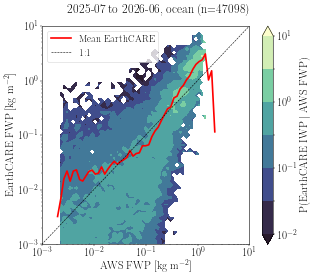

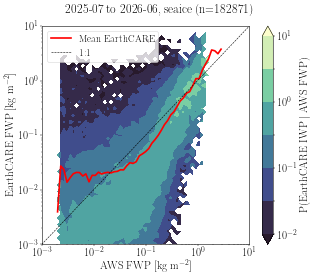

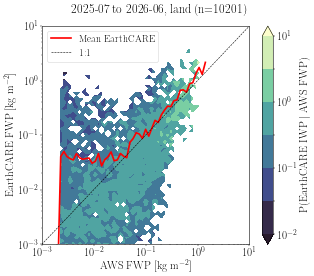

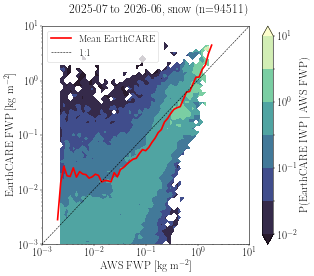

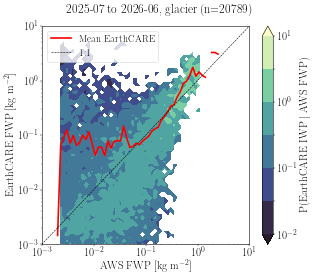

In [12]:
# ------------------------------------------------------------
# data: rows = AWS (x), columns = EarthCARE (y)
# ------------------------------------------------------------
centres = np.sqrt(bins[:-1] * bins[1:])
min_count = 10
levels = np.logspace(-2, 1, 7)

for i_s, surface in enumerate(surface_types):
    joint = h["joint_counts"][i_s]   # rows = EarthCARE, columns = AWS
    total_aws_n = h["aws_n"][i_s]

    p_ea_given_aws, counts_aws, conditional_mean_ea_given_aws = plot_utils.conditional_probability_from_counts(
        joint.T, bins, bins, centres, log=True
    )
    if not np.any(counts_aws >= min_count):
        print(f"{surface}: no AWS bin with {min_count} or more pairs, skipping")
        continue

    # blank empty cells and AWS bins with too few pairs
    p_plot = np.where(p_ea_given_aws > 0, p_ea_given_aws, np.nan)
    p_plot[:, counts_aws < min_count] = np.nan

    # mean and median EarthCARE value in each AWS bin
    with np.errstate(invalid="ignore", divide="ignore"):
        mean_ea = (joint * centres[:, None]).sum(axis=0) / counts_aws
    mean_ea[counts_aws < min_count] = np.nan

    cum = np.cumsum(joint, axis=0)
    median_ea = np.full(joint.shape[1], np.nan)
    for j in range(joint.shape[1]):
        if counts_aws[j] >= min_count:
            median_ea[j] = centres[np.searchsorted(cum[:, j], counts_aws[j] / 2)]

    # ------------------------------------------------------------
    # plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 7))
    cf = ax.contourf(centres, centres, p_plot,
                     levels=levels, norm=LogNorm(), cmap=cmc.cm.deep_r, extend="both")
    fig.colorbar(cf, ax=ax, label=f"P(EarthCARE {ea_label} $|$ AWS {variable_label})")

    ax.plot(centres, conditional_mean_ea_given_aws, color="red", lw=3, label="Mean EarthCARE")
    ax.plot([1e-3, 1e2], [1e-3, 1e2], color="black", ls="--", lw=1, label="1:1")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1e-3, 1e1)
    ax.set_ylim(1e-3, 1e1)
    ax.set_xlabel(rf"AWS {variable_label} [kg m$^{{-2}}$]")
    ax.set_ylabel(rf"EarthCARE {variable_label} [kg m$^{{-2}}$]")

    fig.suptitle(f"{period_label}, {surface} (n={total_aws_n})", fontsize=22)

    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.savefig(f"../figures/collocation_statistics/aws_earthcare_{quantity}_conditional_on_aws_{date_str}_{surface}.png",
                facecolor="white", bbox_inches="tight", dpi=200)